In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
FILE_PATH = "train.csv"
df = pd.read_csv(FILE_PATH)
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [4]:
#Describe data distribution
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


- All columns have a count of 381109 matching the total number of rows so there are no missing values
- Age ranges from 20 to 85 which is a reasonable spread. It has a mean of 38.8 and std of 15.5, a wider spread relative to its mean so it is a potential discriminative feature
- Driving_License has a mean of 0.9979 and std of 0.046 so there is almost no variation to seperate the interested and uninterested customers. 
- Previously_Insured has mean of 0.458 splitting the groups of customers into 2 large groups
- Annual_Premium's mean of 30564 and median of 31669 which is very close. However the max of 540165 is almost 13 times the 75th percentile of 39400 showing that there is a long right tail of high-premium outliers. 
- Response has mean of 0.1226 so there is a severe class imbalance of interested and uninterested customers
- Vintage's quartiles of 82/154/227 is evenly distributed between it's min of 10 and max of 299. It does not cluster around a particular value so its likely a weak predictor
- Region_Code and Policy_Sales_Channel are categorical 

In [5]:
#Check for missing data
df.isna().sum()


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

No missing values found so no imputation or row removal needed

In [6]:
#Check for duplicate rows 
df.duplicated().sum()

np.int64(0)

No duplicate rows found so no imputation or row removal needed

Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64


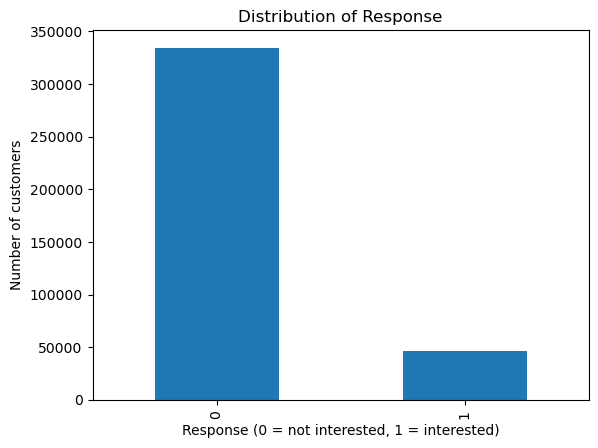

In [7]:
#Understanding distribution of target
col_y = 'Response'

print(df[col_y].value_counts(normalize=True)) #proportion of each class

df[col_y].value_counts().plot(kind='bar') #bar chart for binary data
plt.title("Distribution of Response")
plt.xlabel("Response (0 = not interested, 1 = interested)")
plt.ylabel("Number of customers")
plt.show()

Response is heavily imbalanced. Only 12.3% of customers (class 1) are interested while about 87.7% are not interested (class 0). Accuracy cannot be trusted for evaluation as model would predict "0" for every customer and score high accuracy but fails to identify interested customers 

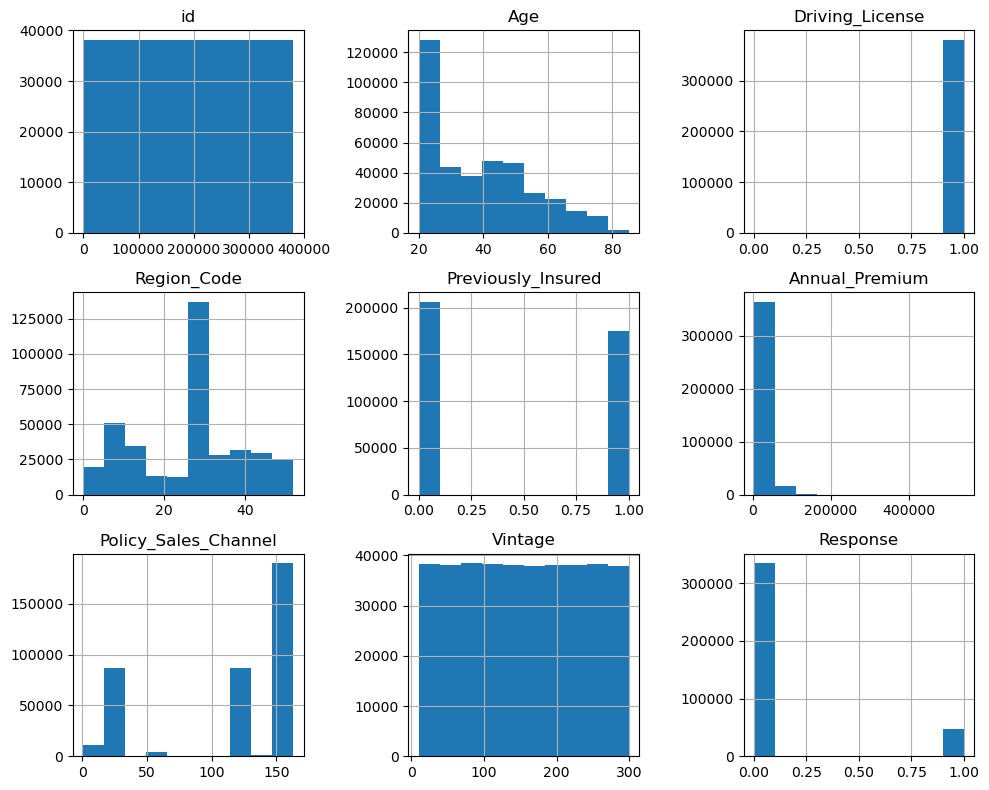

In [8]:
#Plot histogram
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

- id provides no information, should be dropped
- Age has a big spike in the 20s range with a long tail through the 80s range
- Driving_License has almost no variation showing it might be a weak feature for predicting
- Region_Code has groups of customers concentrated in a handful of regions
- Previously insured shows 2 meaningful groups
- Annual_Premium has large cluster of customers at the low end and a long right tail towards max of 540165. 
- Policy_Sales_Channel needs bucketing before encoding
- Vintage is uniform throughout so it might be a weak predictor
- Ressponse is very imbalanced, avoid accuracy as evaluation metric

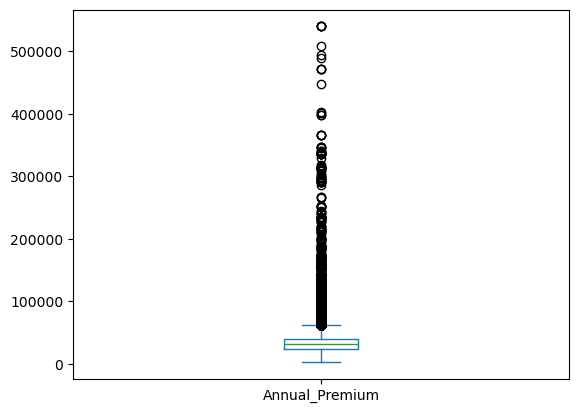

In [9]:
#plot boxplot for Annual_Premium
df['Annual_Premium'].plot(kind='box')
plt.show()

Most customers cluster in the narrow range with many outliers stretching towards the max of 540165. Needs to be compressed. 

In [10]:
#Check datatypes for each column
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all numeric columns

#Display correlation matrix
df_corr = df[col_numeric].corr()
df_corr

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
id,1.000000,0.001561,-0.000564,-0.000572,0.002457,0.003027,-0.002837,-0.000630,-0.001368
Age,0.001561,1.000000,-0.079782,0.042574,-0.254682,0.067507,-0.577826,-0.001264,0.111147
Driving_License,-0.000564,-0.079782,1.000000,-0.001081,0.014969,-0.011906,0.043731,-0.000848,0.010155
Region_Code,-0.000572,0.042574,-0.001081,1.000000,-0.024659,-0.010588,-0.042420,-0.002750,0.010570
Previously_Insured,0.002457,-0.254682,0.014969,-0.024659,1.000000,0.004269,0.219381,0.002537,-0.341170
Annual_Premium,0.003027,0.067507,-0.011906,-0.010588,0.004269,1.000000,-0.113247,-0.000608,0.022575
Policy_Sales_Channel,-0.002837,-0.577826,0.043731,-0.042420,0.219381,-0.113247,1.000000,0.000002,-0.139042
Vintage,-0.000630,-0.001264,-0.000848,-0.002750,0.002537,-0.000608,0.000002,1.000000,-0.001050
Response,-0.001368,0.111147,0.010155,0.010570,-0.341170,0.022575,-0.139042,-0.001050,1.000000


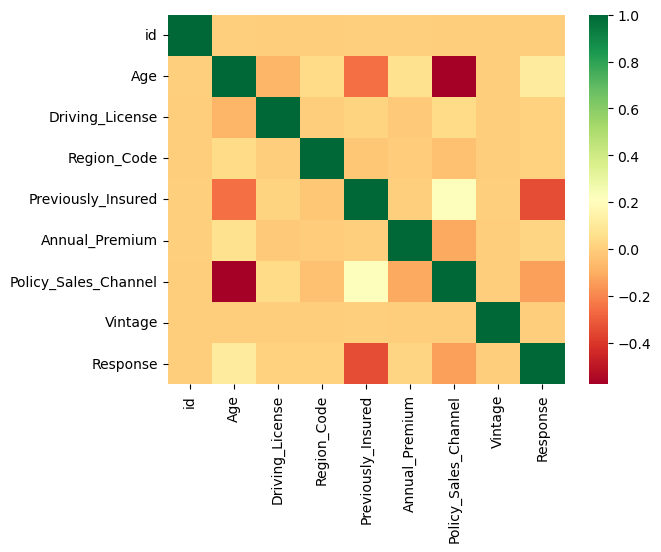

In [11]:
#Plot heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

- Previously_Insured has the strongest negative correlation with Response, strongest numeric predictor
- Age shows mild positive correlation with Response, Policy_Sales_Channel shows mild negative correlation
- Vintage, Annual_premium, Region_Code, Driving_License all have weak correlation with Response

In [12]:
#splits age range into 5 brackets (20-25, 25-30, 30-45, 45-60, 60-85)
age_brackets = pd.cut(df['Age'], bins=[20, 25, 30, 45, 60, 85])
#Groups rows by age_brackets by taking mean of Response in each group
df.groupby(age_brackets, observed=True)['Response'].mean() #observed=True avoids a pandas warning about empty groups

Age
(20, 25]    0.035798
(25, 30]    0.066786
(30, 45]    0.211237
(45, 60]    0.187318
(60, 85]    0.096880
Name: Response, dtype: float64

In [13]:
#Dropping the id column 
df = df.drop(['id'], axis=1) #id is just a row identifier with no predictive value
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...
381104,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


In [14]:
#Convert Region_Code and Policy_Sales_Channel are categories to string
df['Region_Code'] = df['Region_Code'].astype(str)
df['Policy_Sales_Channel'] = df['Policy_Sales_Channel'].astype(str)

In [15]:
#check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all categorical columns

#Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()[:10]}')

Gender (2): ['Male' 'Female']
Region_Code (53): ['28.0' '3.0' '11.0' '41.0' '33.0' '6.0' '35.0' '50.0' '15.0' '45.0']
Vehicle_Age (3): ['> 2 Years' '1-2 Year' '< 1 Year']
Vehicle_Damage (2): ['Yes' 'No']
Policy_Sales_Channel (155): ['26.0' '152.0' '160.0' '124.0' '14.0' '13.0' '30.0' '156.0' '163.0'
 '157.0']


In [16]:
#Keeps the top 10 categories, buckets the rest into 'Other'
#Region_Code and Policy_Sales_Channel are high cardinality and can cause too many columns
#causing curse of dimensionality
def bucket_rare_categories(series, top_n=10, other_label='Other'):
    top_categories = series.value_counts().nlargest(top_n).index #10 most common values
    return series.where(series.isin(top_categories), other_label) #replace the rest with 'Other'

df['Region_Code'] = bucket_rare_categories(df['Region_Code'])
df['Policy_Sales_Channel'] = bucket_rare_categories(df['Policy_Sales_Channel'])

In [17]:
#Split data into features (X) and target (y)
y = df[col_y] #select target column

col_irrelevant = [col_y]
X = df.drop(col_irrelevant, axis=1) #select feature columns

## One-Hot Encoding
X = pd.get_dummies(X,
                   drop_first=True #remove redundant information
                   )
X

,Age,Driving_License,Previously_Insured,Annual_Premium,Vintage,Gender_Male,Region_Code_15.0,Region_Code_28.0,Region_Code_29.0,Region_Code_3.0,...,Policy_Sales_Channel_124.0,Policy_Sales_Channel_151.0,Policy_Sales_Channel_152.0,Policy_Sales_Channel_154.0,Policy_Sales_Channel_156.0,Policy_Sales_Channel_157.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_163.0,Policy_Sales_Channel_26.0,Policy_Sales_Channel_Other
0,44,1,0,40454.0,217,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
1,76,1,0,33536.0,183,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,47,1,0,38294.0,27,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,21,1,1,28619.0,203,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,29,1,1,27496.0,39,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381104,74,1,1,30170.0,88,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
381105,30,1,1,40016.0,131,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
381106,21,1,1,35118.0,161,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
381107,68,1,0,44617.0,74,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [18]:
X.dtypes.value_counts() #shows numeric types to check

bool       24
int64       4
float64     1
Name: count, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

#split data into train set and test set
#X= features, y= target
test_size = 0.3
random_state = 2026 #ensures results are reproducible each run

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=test_size,
                                                    stratify=y, #keeps same 88/12 response class ratio in both train and test
                                                    random_state=random_state)


In [22]:
print("\nTrain balance:\n", y_train.value_counts(normalize=True)) #confirms stratify works and balance is 88/12


Train balance:
 Response
0    0.877437
1    0.122563
Name: proportion, dtype: float64


In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Initialise the model
dt = DecisionTreeClassifier(random_state=2026)
dt.fit(X_train, y_train) #Train on training data

#Evaluate on the test set
from sklearn.metrics import accuracy_score
y_pred_dt = dt.predict(X_test) #predicts Response for each test customer
print("Decision Tree Accuracy: ", accuracy_score(y_test, y_pred_dt)) #compare predictions to real answers

#Save model so it can be reused
import joblib
joblib.dump(dt, 'insurance_dt_model.pkl')

Decision Tree Accuracy:  0.8229907375823253


['insurance_dt_model.pkl']

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

#Initialise the model
gbt = GradientBoostingClassifier(random_state=2026)
gbt.fit(X_train, y_train) ## Train on training data

#Evaluate model
y_pred_gbt = gbt.predict(X_test) #predicts Response for each test customer
print("Gradient Boosted Tree Accuracy: ", accuracy_score(y_test, y_pred_gbt))

#Save model so it can be reused
joblib.dump(gbt, 'insurance_gbt_model.pkl')

Gradient Boosted Tree Accuracy:  0.877419467695241


['insurance_gbt_model.pkl']

In [25]:
from sklearn.ensemble import RandomForestClassifier

#Initialise the model
rf = RandomForestClassifier(random_state=2026)
rf.fit(X_train, y_train) #train on training data

#Evaluate model
y_pred_rf = rf.predict(X_test) #predicts Response for each test customer
print("Random Forest Accuracy: ", accuracy_score(y_test, y_pred_rf))

#Save model so it can be reused
joblib.dump(rf, 'insurance_rf_model.pkl')

Random Forest Accuracy:  0.8605214592462369


['insurance_rf_model.pkl']

All three models score in low to high 80s range. Gradient Boosted Trees score the highest but because of the class imbalance of Response, the model predicts "no" for each customer every time. So accuracy alone cannot tell us whether model actually indentifies interested customers. 